<a href="https://colab.research.google.com/github/pprieri/ml/blob/main/Sarcasm_in_news_headlines_(sentiment_analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#This Notebook performs a Sentiment analysis with a MPL with Embedding layer and extract the Embedding's weight so that they can be visualized in TensorFlow Projector.

#Context
Past studies in Sarcasm Detection mostly make use of Twitter datasets collected using hashtag based supervision but such datasets are noisy in terms of labels and language. Furthermore, many tweets are replies to other tweets and detecting sarcasm in these requires the availability of contextual tweets.

To overcome the limitations related to noise in Twitter datasets, this News Headlines dataset for Sarcasm Detection is collected from two news website. TheOnion aims at producing sarcastic versions of current events and we collected all the headlines from News in Brief and News in Photos categories (which are sarcastic). We collect real (and non-sarcastic) news headlines from HuffPost.

This new dataset has following advantages over the existing Twitter datasets:

Since news headlines are written by professionals in a formal manner, there are no spelling mistakes and informal usage. This reduces the sparsity and also increases the chance of finding pre-trained embeddings.

Furthermore, since the sole purpose of TheOnion is to publish sarcastic news, we get high-quality labels with much less noise as compared to Twitter datasets.

Unlike tweets which are replies to other tweets, the news headlines we obtained are self-contained. This would help us in teasing apart the real sarcastic elements.

More info: https://www.kaggle.com/rmisra/news-headlines-dataset-for-sarcasm-detection?select=Sarcasm_Headlines_Dataset_v2.json

#Set-up

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd './drive/MyDrive/Colab Notebooks/nlp/Data/'

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/nlp/Data


In [12]:
%ls

Sarcasm_Headlines_Dataset.json  Sarcasm_Headlines_Dataset_v2.json


#Load data

In [21]:
def decode_json(file):
  with open(file,'r') as json_file:
    for l in json_file:
      json1 = json.loads(l)
      yield json1

data1 = list(decode_json('Sarcasm_Headlines_Dataset.json'))
data2 = list(decode_json('Sarcasm_Headlines_Dataset_v2.json'))

In [22]:
data1[:3]

[{'article_link': 'https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5',
  'headline': "former versace store clerk sues over secret 'black code' for minority shoppers",
  'is_sarcastic': 0},
 {'article_link': 'https://www.huffingtonpost.com/entry/roseanne-revival-review_us_5ab3a497e4b054d118e04365',
  'headline': "the 'roseanne' revival catches up to our thorny political mood, for better and worse",
  'is_sarcastic': 0},
 {'article_link': 'https://local.theonion.com/mom-starting-to-fear-son-s-web-series-closest-thing-she-1819576697',
  'headline': "mom starting to fear son's web series closest thing she will have to grandchild",
  'is_sarcastic': 1}]

In [28]:
data = pd.DataFrame(data1+data2)
data = data[['headline','is_sarcastic']] #remove article_link
print(f'shape of data: {data.shape}')
data.head()

shape of data: (55328, 2)


,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [90]:
df_train_full = data.sample(frac=0.8,random_state=0)

df_train = df_train_full.sample(frac=0.8, random_state=0)
df_valid = df_train_full.drop(df_train.index)

df_test = data.drop(df_train_full.index)

print(f'shape of train : {df_train.shape}')
print(f'shape of valid : {df_valid.shape}')
print(f'shape of test: {df_test.shape}')

shape of train : (35410, 2)
shape of valid : (8852, 2)
shape of test: (11066, 2)


In [135]:
# Import Tokenizer
vocab_size = 10000
embedding_dim = 16
max_length = 120
trunc_type='post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(oov_token=oov_tok,num_words=vocab_size)
tokenizer.fit_on_texts(df_train['headline'])

word_index = tokenizer.word_index

print(f'Length of word index {len(word_index)}, \n\n Word index: \n {list(word_index.items())[:10]}')

Length of word index 28568, 

 Word index: 
 [('<OOV>', 1), ('to', 2), ('of', 3), ('the', 4), ('in', 5), ('for', 6), ('a', 7), ('on', 8), ('and', 9), ('with', 10)]


In [107]:
def padded_seq(df):

  sentences = df['headline']
  sequences = tokenizer.texts_to_sequences(sentences)
  padded_seq = pad_sequences(sequences, padding=trunc_type, maxlen=max_length) #creates a padded sequence with the length of max(longest sequence, max_length defined in argument)

  return padded_seq  #returns a numpy array

X_train, X_valid, X_test = padded_seq(df_train), padded_seq(df_valid), padded_seq(df_test)

y_train, y_valid, y_test = df_train['is_sarcastic'], df_valid['is_sarcastic'], df_test['is_sarcastic']

In [108]:
print(f'shape of X_train {X_train.shape} \n\n')
X_train

shape of X_train (35410, 120) 




array([[   4,  788, 5429, ...,    0,    0,    0],
       [  54,  116,  921, ...,    0,    0,    0],
       [  48,   81,  178, ...,    0,    0,    0],
       ...,
       [8367, 3445, 4258, ...,    0,    0,    0],
       [ 109, 1981, 2498, ...,    0,    0,    0],
       [ 151, 2265, 4127, ...,    0,    0,    0]], dtype=int32)

In [109]:
print(f'shape of y_train {y_train.shape} \n\n')
y_train

shape of y_train (35410,) 




44750    0
42420    1
37231    0
48199    0
16329    0
        ..
39986    0
35228    0
19472    0
1322     1
51144    0
Name: is_sarcastic, Length: 35410, dtype: int64

### Model


In [110]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

In [117]:
model = tf.keras.Sequential([
                             tf.keras.layers.Embedding(vocab_size, embedding_dim,input_length=max_length), #yields a 2D array
                             tf.keras.layers.Flatten(), #flatten from 2D into a 1D (Global avg pooling )
                             tf.keras.layers.Dense(6,activation='relu'),
                             tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
               optimizer='adam',
               metrics=['accuracy']
)

history = model.fit(X_train, y_train,
          epochs=15,
          validation_data=(X_valid,y_valid),
          callbacks=[early_stopping])

Epoch 1/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.4896 - accuracy: 0.7787 - val_loss: 0.3524 - val_accuracy: 0.8851
Epoch 2/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.2538 - accuracy: 0.9328 - val_loss: 0.2340 - val_accuracy: 0.9111
Epoch 3/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.1139 - accuracy: 0.9663 - val_loss: 0.1958 - val_accuracy: 0.9298
Epoch 4/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.0551 - accuracy: 0.9853 - val_loss: 0.1923 - val_accuracy: 0.9376
Epoch 5/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.0242 - accuracy: 0.9947 - val_loss: 0.2009 - val_accuracy: 0.9398
Epoch 6/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.0110 - accuracy: 0.9982 - val_loss: 0.2185 - val_accuracy: 0.9402
Epoch 7/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.0047 - accuracy: 0.9993 - val_loss: 0.2393 - val_accuracy:

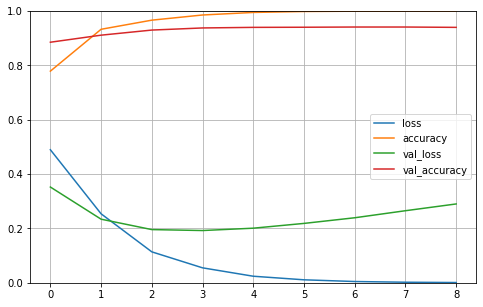

In [118]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [119]:
model.evaluate(X_test,y_test)

346/346 [==============================] - 0s 1ms/step - loss: 0.1827 - accuracy: 0.9419


[0.18270540237426758, 0.9418941140174866]

# Accuracy on Test: 94 %

## Alternative: with GlobalAveragePooling, which will be faster to train. In this case, it yields slightly worse accuracy (90% vs 94%)

In [114]:
model = tf.keras.Sequential([
                             tf.keras.layers.Embedding(vocab_size, embedding_dim,input_length=max_length), #yields a 2D array
                             tf.keras.layers.GlobalAveragePooling1D(), #flatten from 2D into a 1D (Global avg pooling )
                             tf.keras.layers.Dense(6,activation='relu'),
                             tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
               optimizer='adam',
               metrics=['accuracy']
)

history = model.fit(X_train, y_train,
          epochs=15,
          validation_data=(X_valid,y_valid),
          callbacks=[early_stopping])

Epoch 1/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.6595 - accuracy: 0.6192 - val_loss: 0.5718 - val_accuracy: 0.8081
Epoch 2/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.4472 - accuracy: 0.8379 - val_loss: 0.3912 - val_accuracy: 0.8378
Epoch 3/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.3293 - accuracy: 0.8720 - val_loss: 0.3370 - val_accuracy: 0.8554
Epoch 4/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.2771 - accuracy: 0.8939 - val_loss: 0.3071 - val_accuracy: 0.8744
Epoch 5/15
1107/1107 [==============================] - 4s 4ms/step - loss: 0.2422 - accuracy: 0.9084 - val_loss: 0.2898 - val_accuracy: 0.8821
Epoch 6/15
1107/1107 [==============================] - 4s 4ms/step - loss: 0.2164 - accuracy: 0.9190 - val_loss: 0.2786 - val_accuracy: 0.8859
Epoch 7/15
1107/1107 [==============================] - 5s 4ms/step - loss: 0.1947 - accuracy: 0.9296 - val_loss: 0.2717 - val_accuracy:

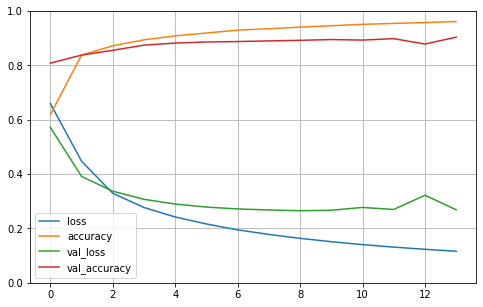

In [116]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [115]:
model.evaluate(X_test,y_test)

346/346 [==============================] - 0s 1ms/step - loss: 0.2516 - accuracy: 0.9012


[0.25158312916755676, 0.9012289643287659]

## Results of Embeddings in Layer 0:

In [126]:
embeddings_layer = model.layers[0]

weights_emb = embeddings_layer.get_weights()[0]

print(f'We are working with a {vocab_size} in our corpus, with Embeddings of {embedding_dim}, so our embeddings will have shape: \n')
print(weights_emb.shape)

We are working with a 10000 in our corpus, with Embeddings of 16, so our embeddings will have shape: 

(10000, 16)


In [129]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

print(decode_review(X_train[3]))
print(df_train.iloc[3,0])

james <OOV> double quick recap of january 2018 is <OOV> just to watch ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?
james corden's double-quick recap of january 2018 is exhausting just to watch


### Review Embeddings in TensorFlow Projector

In [131]:
import io

out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')
for word_num in range(1, vocab_size):
  word = reverse_word_index[word_num]
  embeddings = weights_emb[word_num]
  out_m.write(word + "\n")
  out_v.write('\t'.join([str(x) for x in embeddings]) + "\n")
out_v.close()
out_m.close()

In [132]:
try:
  from google.colab import files
except ImportError:
  pass
else:
  files.download('vecs.tsv')
  files.download('meta.tsv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

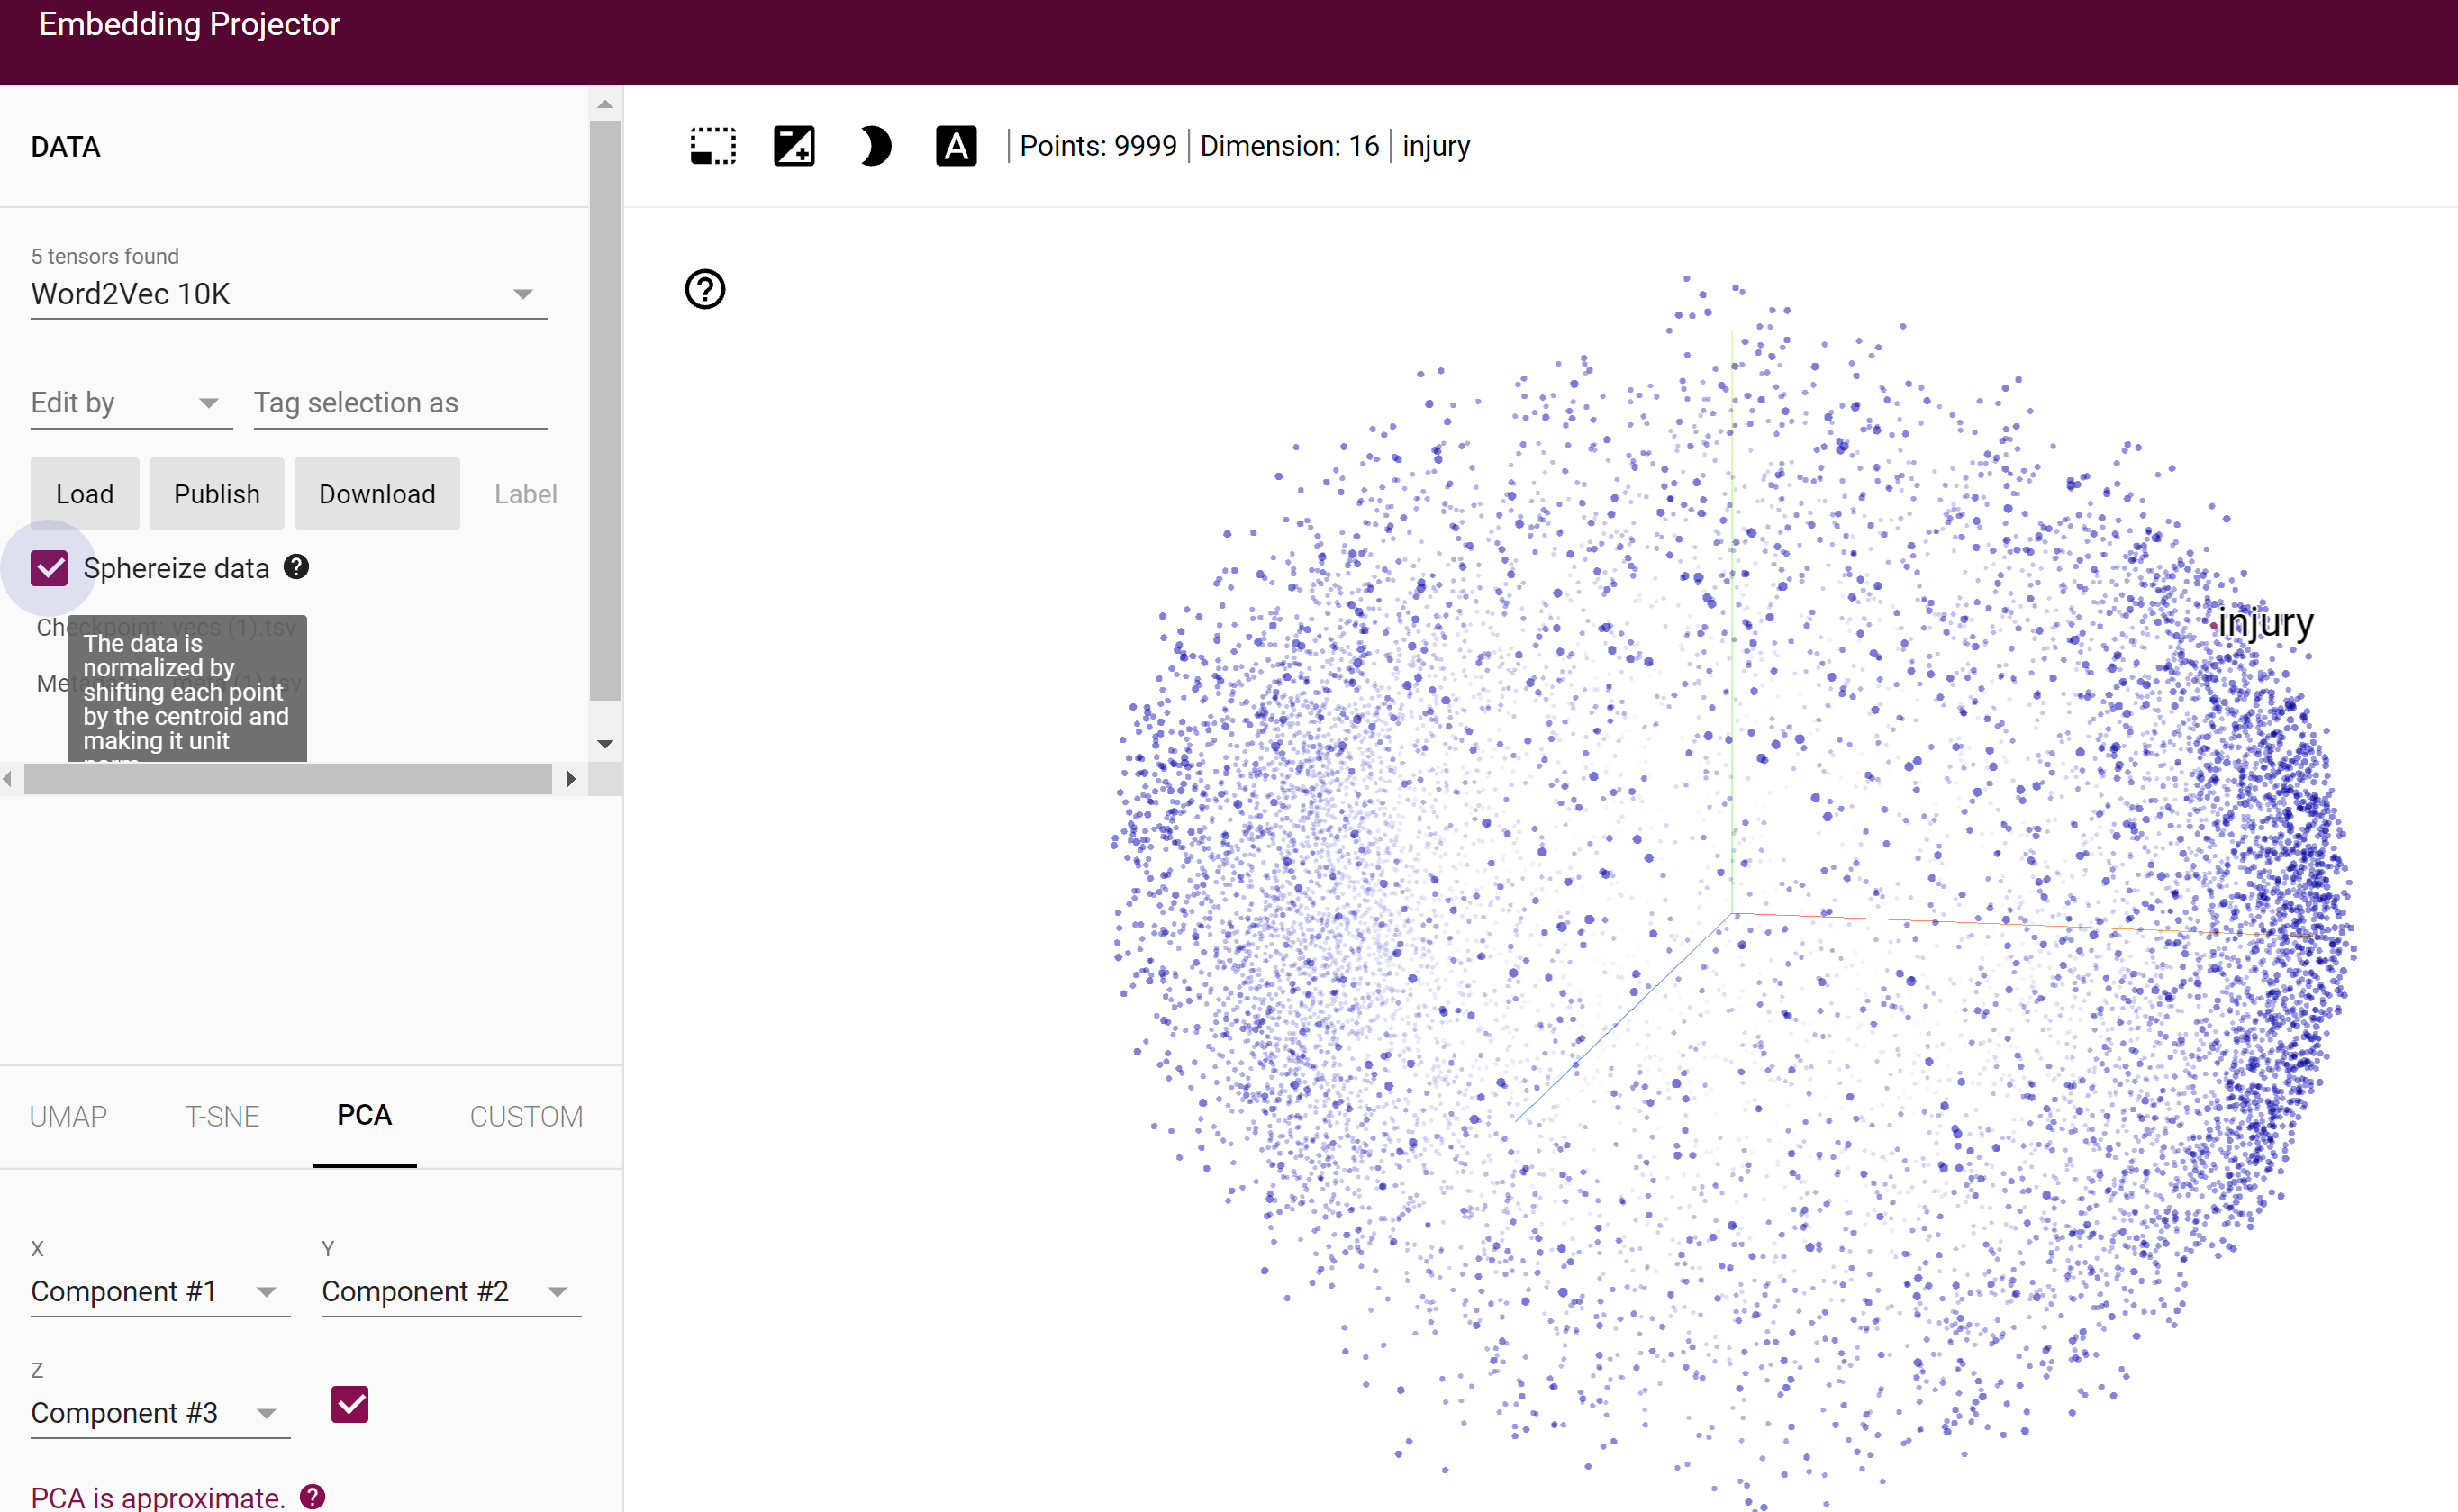